In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from db_connection import get_connection

conn = get_connection()

In [3]:
orders = pd.read_csv("data_orders.csv")
offers = pd.read_csv("data_offers.csv")

In [4]:
orders.shape

(10716, 8)

In [5]:
offers.shape

(334363, 2)

In [6]:
orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [7]:
# order_status_key
# 4 = client cancelled
# 9 = system rejected

In [8]:
orders.columns

Index(['order_datetime', 'origin_longitude', 'origin_latitude', 'm_order_eta',
       'order_gk', 'order_status_key', 'is_driver_assigned_key',
       'cancellations_time_in_seconds'],
      dtype='object')

In [9]:
# Understand the Columns

# Before analyzing we must understand the meaning.

# Column	                                        Meaning
# order_datetime	                -      time order was placed
# origin_longitude	                -           pickup longitude
# origin_latitude	                -            pickup latitude
# m_order_eta	                    -        estimated driver arrival
# order_gk	                        -               order ID
# order_status_key	                -             order outcome
# is_driver_assigned_key	        -         driver assigned or not
# cancellations_time_in_seconds	    -        time until cancellation

In [10]:
df = orders.merge(offers, on="order_gk", how="inner")   # Merge the two datasets on the common key 'order_gk' using an inner join

In [11]:
df.head(15)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0,300050983403
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986179
2,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986174
3,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,300050986180
4,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976275
5,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976284
6,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976283
7,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976271
8,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976274
9,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,300050976278


In [12]:
# clean the dataset

# right now values are hard to read

# therefore we will conver them to labels

In [13]:
df["is_driver_assigned"] = np.where(
    df["is_driver_assigned_key"] == 1,
    "YES",
    "NO"
)

In [14]:
df["order_status"] = np.where(
    df["order_status_key"] == 4,
    "Client Cancelled",
    np.where(
        df["order_status_key"] == 9,
        "System Rejected",
        "Other"
    )
)

In [15]:
# drop unnecessary columns
df.drop(columns=["is_driver_assigned_key", "order_status_key"], inplace=True)

In [16]:
# Rename Columns

# Why we do this

# Simplifies column names.

df.rename(columns={"order_datetime": "order_time"}, inplace=True)

In [17]:
df["order_hour"] = df["order_time"].str.split(":").str[0]

In [18]:
# Analysis #1 - Failure Reasons
query = """
SELECT 
is_driver_assigned_key,
order_status_key,
COUNT(order_gk) AS orders
FROM orders
GROUP BY is_driver_assigned_key, order_status_key
"""

In [19]:
conn = get_connection()

failure_distribution = pd.read_sql(query, conn)

failure_distribution["driver_status"] = failure_distribution["is_driver_assigned_key"].map({
    0: "No Driver Assigned",
    1: "Driver Assigned"
})

failure_distribution["order_status"] = failure_distribution["order_status_key"].map({
    4: "Client Cancelled",
    9: "System Reject"
})

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\845632369.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  failure_distribution = pd.read_sql(query, conn)


In [20]:
failure_distribution["category"] = (
    failure_distribution["driver_status"] + " - " + failure_distribution["order_status"]
)

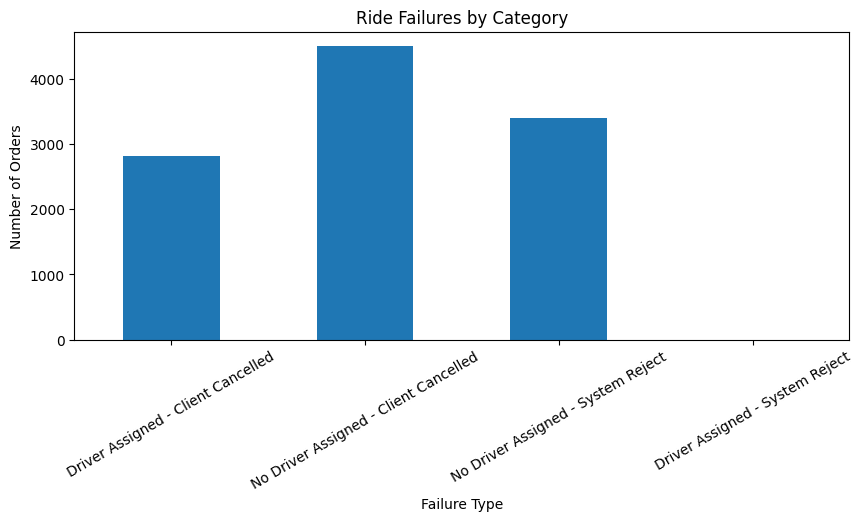

In [21]:
# visualize failures

failure_distribution.plot(
    x="category",
    y="orders",
    kind="bar",
    figsize=(10,4),
    legend=False
)

plt.title("Ride Failures by Category")
plt.xlabel("Failure Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

In [22]:
# Key Insight (very important)

# Most ride failures occur before a driver is assigned.

# Specifically:

# Client cancellations without driver assigned (~4500) are the largest category.

# System rejects (~3400) also happen before driver assignment.

# Once a driver is assigned, failures drop significantly.

In [23]:
# The platform struggles to match riders with drivers quickly enough.
# Many riders cancel before a driver is assigned.

# This is a supply–demand matching problem.

In [24]:
# Business Interpretation

# Possible reasons:

# 1️⃣ Driver shortage during high demand periods
# 2️⃣ Slow matching algorithm
# 3️⃣ Long ETA discouraging riders

# Platforms like Uber and Lyft track this metric carefully because matching delay directly impacts revenue and user retention.

In [25]:
# Recommendations:

# Improve driver dispatch algorithms

# Increase driver incentives during peak hours

# Reduce matching latency

In [26]:
# Analysis #2 — Failure Distribution by Hour of the Day
query_hourly_failures = """
SELECT
    HOUR(order_datetime) AS hour,   -- extracts hour from time
    COUNT(*) AS failed_orders       -- counts failed rides
FROM orders
GROUP by hour                       -- aggregates per hour
ORDER BY hour;                      -- sort from 0 to 23 hours
"""

In [27]:
# This analysis answers:
# When do ride failures peak during the day?
# Are there rush-hour problems?
# Are failures due to driver shortage at certain times?

In [28]:
# load into pandas

hourly_failures = pd.read_sql(query_hourly_failures, conn)
hourly_failures

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\168501031.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  hourly_failures = pd.read_sql(query_hourly_failures, conn)


,hour,failed_orders
0,0,683
1,1,471
2,2,555
3,3,513
4,4,152
5,5,67
6,6,159
7,7,447
8,8,1082
9,9,412


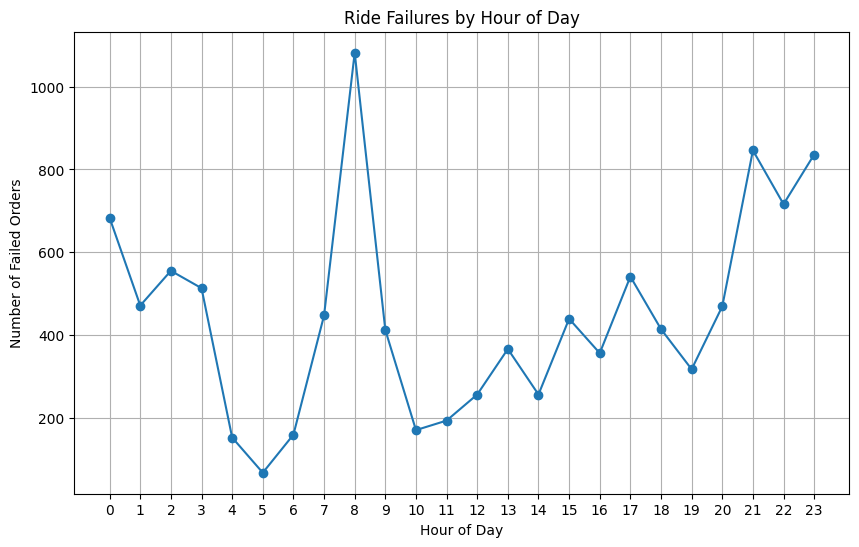

In [29]:
# plot the trend

plt.figure(figsize=(10,6))

plt.plot(
    hourly_failures["hour"],
    hourly_failures["failed_orders"],
    marker="o"
)

plt.title("Ride Failures by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Failed Orders")
plt.xticks(range(24))

plt.grid(True)
plt.show()

In [30]:
# Major Insight
# Peak failures occur during morning commute and late evening

# Two clear spikes:

# Morning spike

# 7 → 447
# 8 → 1082 (highest)
# 9 → 412

# Night spike

# 21 → 846
# 22 → 716
# 23 → 836

# This pattern strongly suggests demand surges that the driver supply cannot handle.

In [31]:
# Business Interpretation

# Morning peak (~8 AM):

# commuters going to work

# sudden ride demand

# drivers not yet active or insufficient supply

# Night peak (~9–11 PM):

# people returning home

# entertainment/nightlife demand

# fewer drivers available late night

# This results in:

# Demand > Driver Supply → Matching delays → Ride failures

In [32]:
# Recommendation:

# The platform should increase driver incentives during
# these high-demand windows to improve driver availability
# and reduce ride failure rates.

In [33]:
# Analysis #3: ETA vs Ride Failure.

query_eta = """
SELECT 
    m_order_eta,
    COUNT(*) AS failed_orders
FROM orders
WHERE m_order_eta IS NOT NULL
GROUP BY m_order_eta
ORDER BY m_order_eta
"""

In [34]:
# This is one of the strongest analyses in the whole dataset 
# because it explains why customers cancel. Companies like Uber 
# and Lyft closely monitor ETA because longer wait times directly 
# increase cancellations.


# We want to answer:

# Do longer estimated arrival times (ETA) 
# lead to more ride failures?

In [35]:
# Load Data into Python

conn = get_connection()

eta_failures = pd.read_sql(query_eta, conn)

eta_failures.head(15)

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\3876286517.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eta_failures = pd.read_sql(query_eta, conn)


,m_order_eta,failed_orders
0,0.0,7902
1,60.0,245
2,95.0,1
3,102.0,1
4,104.0,1
5,109.0,1
6,110.0,1
7,111.0,3
8,113.0,5
9,114.0,2


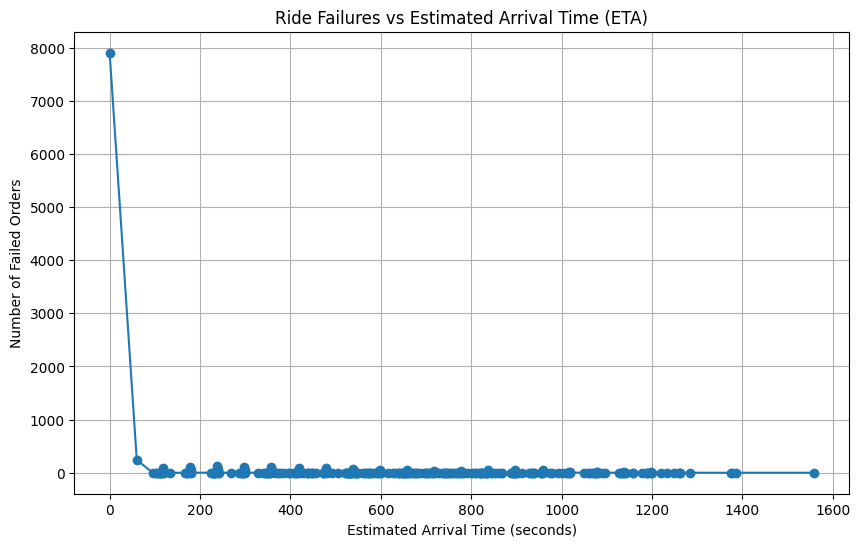

In [36]:
# Plot the Relationship

plt.figure(figsize=(10,6))

plt.plot(
    eta_failures["m_order_eta"],
    eta_failures["failed_orders"],
    marker="o"
)

plt.title("Ride Failures vs Estimated Arrival Time (ETA)")
plt.xlabel("Estimated Arrival Time (seconds)")
plt.ylabel("Number of Failed Orders")

plt.grid(True)
plt.show()

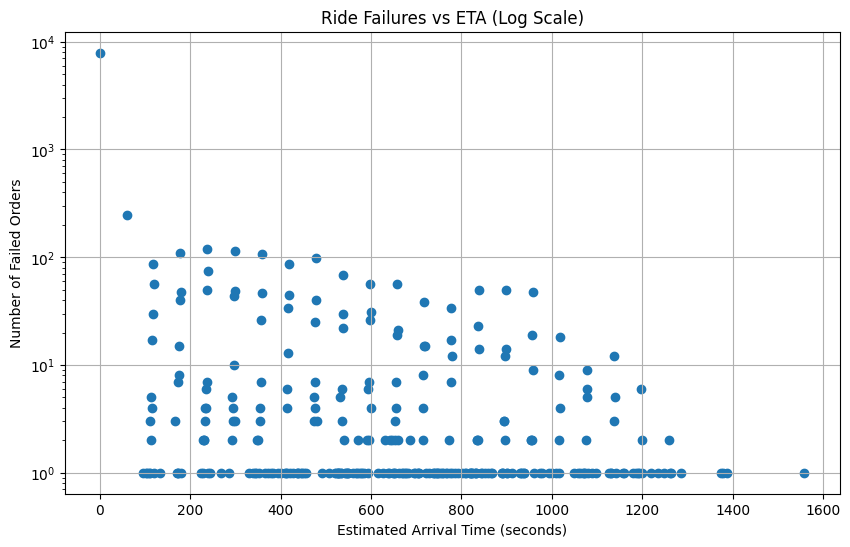

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    eta_failures["m_order_eta"],
    eta_failures["failed_orders"]
)

plt.yscale("log")

plt.title("Ride Failures vs ETA (Log Scale)")
plt.xlabel("Estimated Arrival Time (seconds)")
plt.ylabel("Number of Failed Orders")

plt.grid(True)
plt.show()

In [38]:
# Core Insight

# Your analysis suggests:

# Primary failure driver → driver matching failure
# Secondary factor → long wait time

# So the system issue is mainly:

# Supply shortage of drivers

# not necessarily slow drivers.

In [39]:
# Insight:

# Most ride failures occur when ETA = 0, indicating that a driver
# was never assigned to the request.

# This confirms that the primary cause of failed rides is the
# inability of the platform to match riders with available drivers.

# For rides with assigned drivers, failure counts increase slightly
# as ETA approaches ~120 seconds, suggesting that longer waiting
# times can contribute to cancellations.

# Overall, driver availability appears to be a more critical factor
# than driver arrival time.

In [40]:
# Recommendation:

# Improving driver availability and matching efficiency may have a
# greater impact on reducing ride failures than optimizing arrival time.

In [41]:
# We will map ride failure hotspots using H3 hexagons.

# H3 → hexagonal spatial clustering
# Folium → interactive maps

# create hexagon cell

# Import the correct H3 API
from h3.api import basic_int as h3_api

# Create hexagon ID for each ride request
df["hex_id"] = df.apply(
    lambda row: h3_api.latlng_to_cell(
        row["origin_latitude"],
        row["origin_longitude"],
        8
    ),
    axis=1
)

In [42]:
# What this does

# Every ride request gets assigned to a hexagonal grid cell.

# Resolution 8 = city-level grid size.

In [43]:
# count failures per hexagon

hex_counts = df.groupby("hex_id")["order_gk"].count().reset_index()
hex_counts.rename(columns={"order_gk": "failures"}, inplace=True)

hex_counts.head()

,hex_id,failures
0,612935755624349695,65
1,612935755626446847,14
2,612935755628543999,10
3,612935755630641151,3
4,612935755632738303,46


In [44]:
# create the map

import folium

map_center = [
    df["origin_latitude"].mean(),
    df["origin_longitude"].mean()
]

m = folium.Map(location=map_center, zoom_start=11)

In [45]:
# convert hexagons to polygons because Folium needs polygons to plot

from h3.api import basic_int as h3_api

def hex_to_polygon(hex_id):
    boundary = h3_api.cell_to_boundary(hex_id)
    return [[lat, lng] for lat, lng in boundary]

In [46]:
import numpy as np
import matplotlib

colormap = matplotlib.colormaps["plasma"]
max_failures = hex_counts["failures"].max()

for _, row in hex_counts.iterrows():

    polygon = hex_to_polygon(row["hex_id"])

    # normalize with log scale
    normalized = np.log1p(row["failures"]) / np.log1p(max_failures)

    color = matplotlib.colors.to_hex(colormap(normalized))

    folium.Polygon(
    locations=polygon,
    color="black",
    weight=1,
    fill=True,
    fill_color=color,
    fill_opacity=0.7,
    tooltip=f"Failures: {row['failures']}"
).add_to(m)

In [47]:
from branca.colormap import LinearColormap

legend = LinearColormap(
    colors=["purple", "pink", "orange", "yellow"],
    vmin=hex_counts["failures"].min(),
    vmax=hex_counts["failures"].max(),
)

legend.caption = "Number of Ride Failures per Hexagon"

legend.add_to(m)

In [48]:
m.save("ride_failure_hotspots.html")

In [49]:
# ==============================================
# Geographic Analysis of Ride Failures
# ==============================================

# Why we did this analysis:
# We want to understand where ride failures happen most often in the city.
# Sometimes ride failures are not only caused by time or ETA,
# but also by location.

# Certain areas may have more ride failures because:
# - not enough drivers
# - very high ride demand
# - traffic congestion
# - drivers being far away

In [50]:
# ==============================================
# Business Recommendations
# ==============================================

# Based on this geographic analysis, the platform could:

# 1. Increase driver incentives in high-failure areas
#    to attract more drivers to those locations.

# 2. Improve the driver matching algorithm so nearby
#    drivers are assigned faster.

# 3. Use surge pricing or bonuses in high-demand zones.

# 4. Reposition drivers toward high demand areas
#    during peak hours.

# These actions could reduce ride failures and improve
# the overall reliability of the platform.

In [51]:
# create the failure indicator

df["is_failed"] = df["order_status"].isin(
    ["Client Cancelled", "System Rejected"]
)

In [52]:
print (df["is_failed"])

0        True
1        True
2        True
3        True
4        True
         ... 
31263    True
31264    True
31265    True
31266    True
31267    True
Name: is_failed, Length: 31268, dtype: bool


In [53]:
# Note: The dataset only contains failed ride requests.
# Therefore overall failure rate cannot be calculated.
# Instead we analyze the causes of failures.

In [54]:
# Analysis #4 — Driver Assignment Rate

query_driver_assignment = """
SELECT
    is_driver_assigned_key,
    COUNT(*) AS total_orders
FROM orders
GROUP BY is_driver_assigned_key
"""

driver_assignment = pd.read_sql(query_driver_assignment, conn)

driver_assignment

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\856708482.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  driver_assignment = pd.read_sql(query_driver_assignment, conn)


,is_driver_assigned_key,total_orders
0,1,2814
1,0,7902


In [55]:
# Why we are doing this:
# We want to measure how often drivers are successfully assigned
# to ride requests.

# If many orders have no driver assigned, it indicates
# a supply shortage of drivers on the platform.

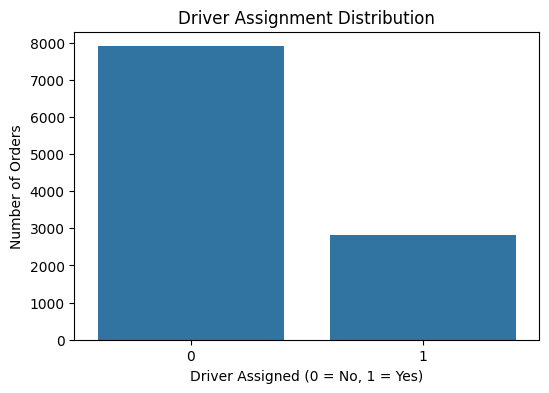

In [56]:
# visualization

plt.figure(figsize=(6,4))

sns.barplot(
    data=driver_assignment,
    x="is_driver_assigned_key",
    y="total_orders"
)

plt.title("Driver Assignment Distribution")
plt.xlabel("Driver Assigned (0 = No, 1 = Yes)")
plt.ylabel("Number of Orders")

plt.show()

In [57]:
# Insight:
# The majority of ride requests do not receive a driver assignment.
# This indicates that the platform does not have enough available
# drivers to meet rider demand.
#
# Because a driver is not assigned quickly, many riders cancel
# their requests or the system rejects the ride.

In [58]:
# calculate the percentage

total_orders = driver_assignment["total_orders"].sum()

driver_assignment["percentage"] = (
    driver_assignment["total_orders"] / total_orders * 100
)

driver_assignment

,is_driver_assigned_key,total_orders,percentage
0,1,2814,26.259798
1,0,7902,73.740202


In [59]:
# Business Interpretation:
# Only a small percentage of ride requests receive a driver.
# This suggests a supply-demand imbalance where the number
# of riders exceeds the available drivers on the platform.

In [60]:
# Why this matters:
# Ride-hailing platforms like Uber, Lyft, and Gett depend on
# efficient driver-rider matching.
#
# If many ride requests cannot be matched with drivers,
# users experience cancellations and poor service reliability.

In [61]:
# Recommendation:
# To reduce ride failures, the platform could:
#
# 1. Increase driver incentives during peak demand hours.
# 2. Improve the driver dispatch algorithm.
# 3. Encourage drivers to operate in high-demand areas.

In [62]:
# Analysis #5 — Failure Type by Hour

# this answers - Why they happen at that time

query_failure_hour_type = """
SELECT
    HOUR(order_datetime) AS hour,
    order_status_key,
    COUNT(*) AS failures
FROM orders
GROUP BY hour, order_status_key
ORDER BY hour
"""

failure_hour_type = pd.read_sql(query_failure_hour_type, conn)

failure_hour_type

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\3034239648.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  failure_hour_type = pd.read_sql(query_failure_hour_type, conn)


,hour,order_status_key,failures
0,0,4,418
1,0,9,265
2,1,4,307
3,1,9,164
4,2,4,315
5,2,9,240
6,3,4,288
7,3,9,225
8,4,4,91
9,4,9,61


In [63]:
# Why we are doing this analysis:
# Previously we identified when ride failures happen.
# Now we want to understand what type of failures occur
# during different hours of the day.

# order_status_key meanings:
# 4 = Client Cancelled
# 9 = System Rejected

In [64]:
# prepare data for plotting

failure_hour_pivot = failure_hour_type.pivot(
    index="hour",
    columns="order_status_key",
    values="failures"
)

failure_hour_pivot

order_status_key,4,9
hour,,
0,418,265
1,307,164
2,315,240
3,288,225
4,91,61
5,40,27
6,114,45
7,320,127
8,727,355


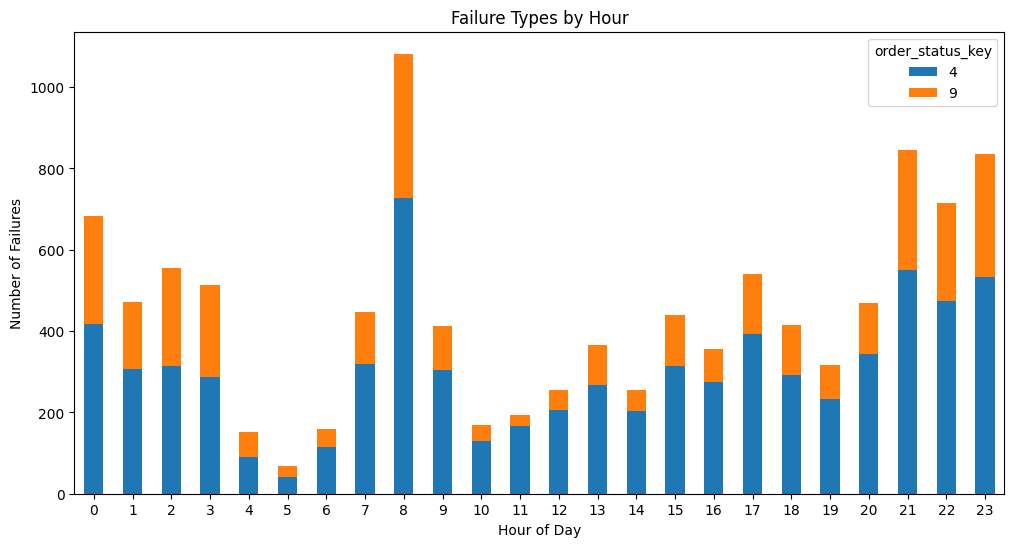

In [65]:
# visualization

failure_hour_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Failure Types by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Failures")

plt.xticks(rotation=0)

plt.show()

In [66]:
# The bar is stacked:

# Blue → Client Cancelled (status 4)

# Orange → System Rejected (status 9)

In [67]:
# Morning Peak (8 AM)

# hour 8
# Client Cancelled = 727
# System Rejected = 355
# Total ≈ 1082 failures

# Morning commute demand is extremely high.
# Many riders request rides at the same time,
# which overwhelms the driver supply.

In [68]:
# Late Night Peak (21–23)

# hour 21
# Client Cancelled = 550
# System Rejected = 296

# Night-time failures are also high.
# This suggests that driver availability drops at night
# while demand remains strong.

In [69]:
# Client Cancellations Are Always Higher

# Across almost every hour:
# Client Cancelled > System Rejected

In [70]:
# The platform does not reject most rides immediately.
# Instead, riders cancel first because they wait too long
# for a driver assignment.

# This reinforces your earlier finding:
# Driver supply shortage is the primary cause of ride failures.

In [71]:
# Business Interpretation:
# The majority of failures are caused by riders cancelling
# their requests rather than the system rejecting them.

# This suggests that riders lose patience when drivers
# are not assigned quickly enough.

In [72]:
# Recommendation:
# To reduce ride failures, the platform could:

# 1. Increase driver availability during peak hours.
# 2. Improve the driver-rider matching algorithm.
# 3. Offer surge incentives to drivers during demand spikes.

In [73]:
# Analysis #6 — Average Cancellation Time by Hour

# This calculates:
# Average time users wait before cancelling rides for each 
# hour of the day.

query_cancel_time = """
SELECT
    HOUR(order_datetime) AS hour,
    AVG(cancellations_time_in_seconds) AS avg_cancel_time
FROM orders
WHERE cancellations_time_in_seconds IS NOT NULL
GROUP BY hour
ORDER BY hour
"""

cancel_time_hourly = pd.read_sql(query_cancel_time, conn)

cancel_time_hourly

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\3974517766.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cancel_time_hourly = pd.read_sql(query_cancel_time, conn)


,hour,avg_cancel_time
0,0,100.260615
1,1,91.910828
2,2,88.079279
3,3,82.077973
4,4,95.210526
5,5,144.582090
6,6,133.220126
7,7,107.243848
8,8,100.927911
9,9,125.080097


In [74]:
# Why we are doing this:
# We want to understand how long users are willing to wait
# before cancelling a ride request.

# If cancellation times are short, it means riders
# lose patience quickly when drivers are not assigned.

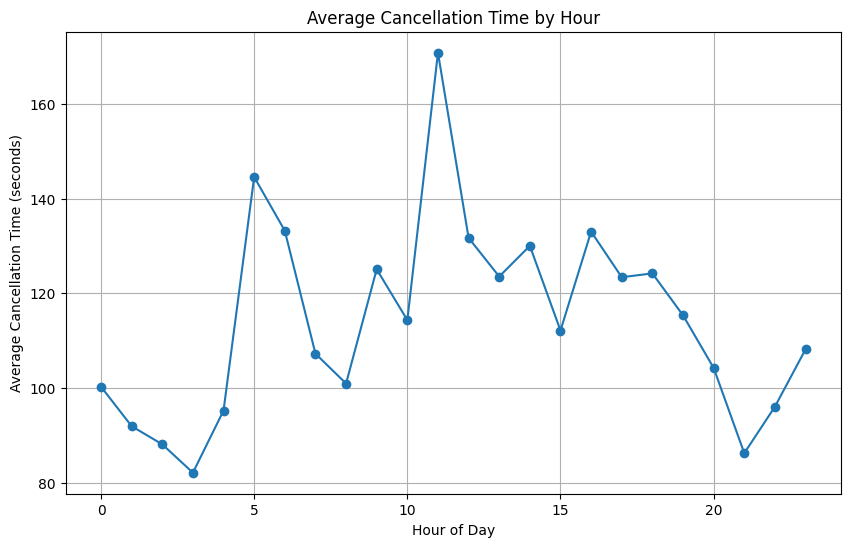

In [75]:
# visualization

plt.figure(figsize=(10,6))

plt.plot(
    cancel_time_hourly["hour"],
    cancel_time_hourly["avg_cancel_time"],
    marker="o"
)

plt.title("Average Cancellation Time by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Cancellation Time (seconds)")

plt.grid(True)

plt.show()

In [76]:
# Highest Cancellation Wait Time → 11 AM
# 11 AM → ~170 seconds

# Meaning:

# Around late morning, riders are willing to wait longer
# before cancelling their ride requests.


# Possible reason:

# moderate demand
# riders expect drivers to arrive soon

In [77]:
# Early Morning Cancellations Are Faster
# 3 AM → ~82 seconds

# Meaning:

# Late night / early morning riders cancel faster.
# This could happen because very few drivers are available,
# so riders quickly realize no driver will be assigned.

In [78]:
# Evening Cancellations Also Faster
# 9 PM → ~86 seconds

# Meaning:

# During night hours riders lose patience quickly
# if a driver is not assigned immediately.


# Possible reasons:

# driver shortage
# high demand
# riders switching to other apps

In [79]:
# Business Interpretation:

# Riders are willing to wait roughly 1–3 minutes
# for a driver assignment.

# If a driver is not assigned within this time window,
# many users cancel the request.

# This indicates that driver matching latency
# directly affects ride failure rates.

In [80]:
# Recommendations:

# 1. Improve driver matching speed so drivers are assigned
#    within the first 1–2 minutes.

# 2. Increase driver supply during peak demand hours.

# 3. Notify nearby drivers more aggressively to accept rides faster.

# 4. Use dynamic incentives during high-demand periods.

In [81]:
# Analysis #7 — Ride Failure Distribution by ETA Group

query_eta_group = """
SELECT
    CASE
        WHEN m_order_eta < 60 THEN 'Short ETA'
        WHEN m_order_eta < 120 THEN 'Medium ETA'
        ELSE 'Long ETA'
    END AS eta_group,
    COUNT(*) AS failures
FROM orders
WHERE m_order_eta IS NOT NULL
GROUP BY eta_group
ORDER BY failures DESC;
"""

eta_failure_groups = pd.read_sql(query_eta_group, conn)

eta_failure_groups

C:\Users\sayon\AppData\Local\Temp\ipykernel_16636\4243531109.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eta_failure_groups = pd.read_sql(query_eta_group, conn)


,eta_group,failures
0,Short ETA,7902
1,Long ETA,2360
2,Medium ETA,454


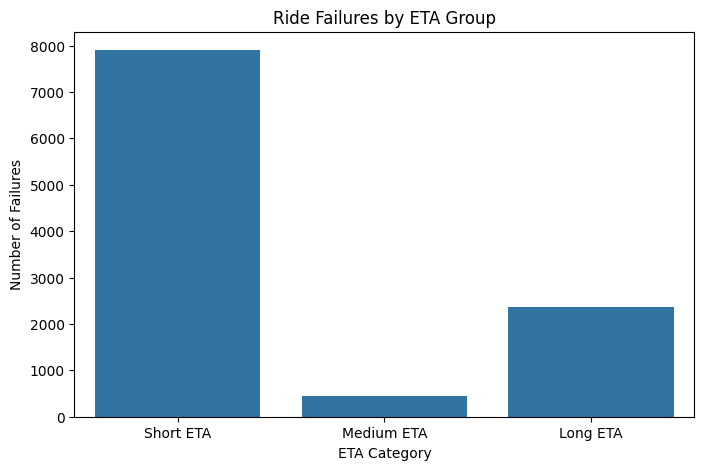

In [82]:
# Visualize the failures across ETA groups

plt.figure(figsize=(8,5))

order = ["Short ETA", "Medium ETA", "Long ETA"]

sns.barplot(
    data=eta_failure_groups,
    x="eta_group",
    y="failures",
    order=order
)

plt.title("Ride Failures by ETA Group")
plt.xlabel("ETA Category")
plt.ylabel("Number of Failures")

plt.show()

In [83]:
# Why Short ETA Has The Most Failures

# Because most orders in the dataset have Short ETA.

# So naturally:
# More orders → more failures

# This does NOT mean short ETA is worse.
# It just means short ETA requests are more common.


# So the real problem is:

# Driver matching failure
# Not ETA length.

In [84]:
# ==============================================
# Insight
# ==============================================

# Most ride failures occur in the Short ETA category.

# However, this does NOT mean that short ETA causes failures.

# It simply indicates that most ride requests in the dataset
# have short estimated arrival times.

# Therefore, more failures appear in this category because
# it contains the largest number of ride requests.

In [85]:
# Business Interpretation

# Ride failures are not primarily caused by long ETAs.

# Instead, the main issue is that drivers are not
# assigned quickly enough to ride requests.

# When no driver is assigned within the first
# 1–2 minutes, many riders cancel the request.

In [86]:
# Recommendations

# 1. Improve the driver-rider matching algorithm.

# 2. Increase driver availability during peak hours.

# 3. Prioritize dispatching drivers to high-demand zones.

# 4. Reduce the time required to assign a driver 
# after a ride request is placed.

In [87]:
# Filter rides requested at 8 AM

df["order_hour"] = df["order_hour"].astype(int)

peak_8am = df[df["order_hour"] == 8]

peak_8am.shape

# This gives the total failed rides at 8 AM.

(3865, 12)

In [88]:
# Identify Cancellations Before Driver Assignment

cancel_no_driver = peak_8am[
    (peak_8am["order_status"] == "Client Cancelled") &
    (peak_8am["is_driver_assigned"] == "NO")
]

cancel_no_driver.shape

(1447, 12)

In [89]:
# Simulate 10% Driver Supply Increase

# If driver supply increases 10%, we assume 10% of unassigned cancellations could have been matched.

import numpy as np

simulation = cancel_no_driver.copy()

# number of rides potentially saved
rides_saved = int(len(simulation) * 0.10)

rides_saved

144

In [90]:
# Calculate New Cancellation Rate

original_cancellations = len(cancel_no_driver)

new_cancellations = original_cancellations - rides_saved

reduction_percentage = (rides_saved / original_cancellations) * 100

print("Original cancellations:", original_cancellations)
print("New cancellations:", new_cancellations)
print("Cancellation reduction (%):", reduction_percentage)

Original cancellations: 1447
New cancellations: 1303
Cancellation reduction (%): 9.95162404975812


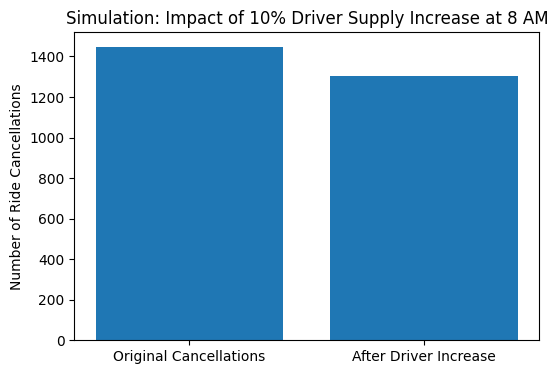

In [91]:
# Visualize Impact

import matplotlib.pyplot as plt

labels = ["Original Cancellations", "After Driver Increase"]
values = [original_cancellations, new_cancellations]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Simulation: Impact of 10% Driver Supply Increase at 8 AM")
plt.ylabel("Number of Ride Cancellations")

plt.show()

In [ ]:
# Analytical Insight

# This simulation suggests that even a small increase in driver 
# availability during demand spikes can significantly reduce ride failures.

# Since riders cancel after 1–3 minutes of waiting, improving driver supply 
# during peak demand windows increases the probability of successful ride matching.

In [ ]:
# Business Interpretation

# Ride failures during peak hours are largely driven by:

# Demand spike
# ↓
# Insufficient drivers
# ↓
# Delayed driver assignment
# ↓
# User cancellation

# Increasing driver supply during peak periods can:

# reduce cancellations

# improve ride completion rate

# increase platform reliability

In [ ]:
# Operational Recommendation

# Ride-hailing platforms could reduce failures by:

# Offering targeted driver incentives during the 8 AM peak
# Encouraging drivers to go online earlier
# Repositioning drivers toward high-demand areas
# These strategies would help balance supply and demand during critical demand spikes.